In [53]:
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
from google.colab import drive

%matplotlib inline

In [54]:

drive.mount('/content/drive')

ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/machine learning/datasets/pathmnist.npz'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
data_npz = np.load(ruta_dataset)

X_raw = np.concatenate([data_npz['train_images'], data_npz['val_images'], data_npz['test_images']], axis=0)
y_raw = np.concatenate([data_npz['train_labels'], data_npz['val_labels'], data_npz['test_labels']], axis=0).ravel()

print(f"Forma original de las imágenes: {X_raw.shape}")
print(f"Forma original de las etiquetas: {y_raw.shape}")
print(f"Total de ejemplos (m): {X_raw.shape[0]}")

Forma original de las imágenes: (107180, 28, 28, 3)
Forma original de las etiquetas: (107180,)
Total de ejemplos (m): 107180


In [56]:
m_total = X_raw.shape[0]
X_flat = X_raw.reshape(m_total, -1)

df = pd.DataFrame(X_flat)
df['label'] = y_raw

print("\nDistribución original de clases:")
print(df['label'].value_counts().sort_index())

min_count = df['label'].value_counts().min()
df_balanced = df.groupby('label').sample(n=min_count, random_state=42).reset_index(drop=True)

print("\nDistribución de clases (Verificación de balance exacto):")
print(df_balanced['label'].value_counts().sort_index())

X_pd = df_balanced.drop(columns=['label']).values
y_pd = df_balanced['label'].values.astype(int)
X_norm = X_pd / 255.0

m_balanceado = X_norm.shape[0]
print(f"\nTotal de ejemplos después de balancear: {m_balanceado}")
print(f"Forma de X_norm: {X_norm.shape}")
print(f"Forma de y_pd: {y_pd.shape}")


Distribución original de clases:
label
0    11745
1    11413
2    11851
3    12191
4     9931
5    14128
6     9504
7    10867
8    15550
Name: count, dtype: int64

Distribución de clases (Verificación de balance exacto):
label
0    9504
1    9504
2    9504
3    9504
4    9504
5    9504
6    9504
7    9504
8    9504
Name: count, dtype: int64

Total de ejemplos después de balancear: 85536
Forma de X_norm: (85536, 2352)
Forma de y_pd: (85536,)


**División 80% entrenamiento y 20% prueba**

In [57]:
np.random.seed(42)
indices = np.random.permutation(m_balanceado)

train_size = int(0.80 * m_balanceado)
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, y_train = X_norm[train_idx], y_pd[train_idx]
X_test, y_test = X_norm[test_idx], y_pd[test_idx]

print(f"Muestras para Entrenamiento (80%): {X_train.shape[0]}")
print(f"Muestras para Prueba (20%):        {X_test.shape[0]}")

Muestras para Entrenamiento (80%): 68428
Muestras para Prueba (20%):        17108


**Visualización de las muestras de Tejido:**

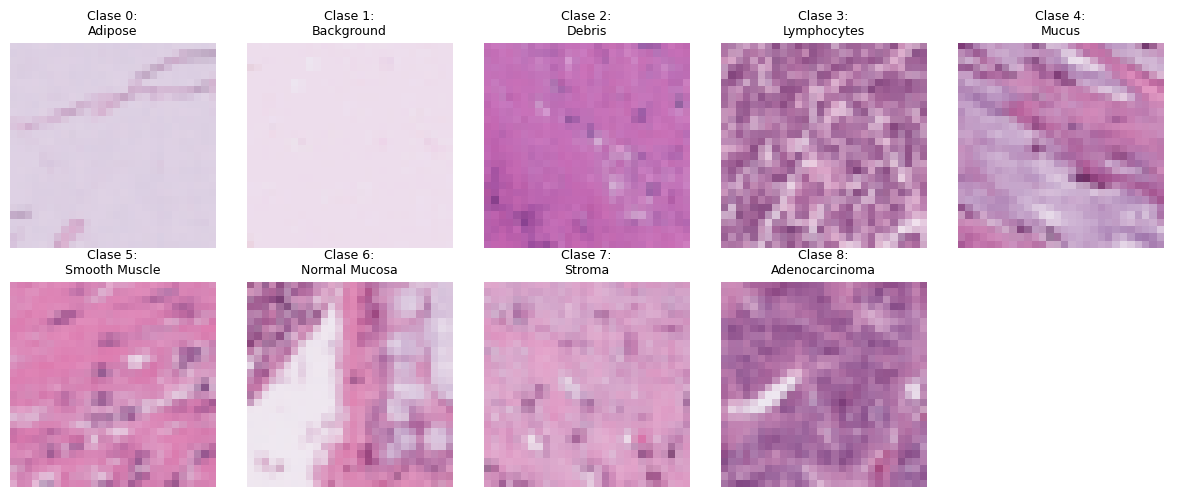

In [58]:
class_names = {
    0: 'Adipose', 1: 'Background', 2: 'Debris',
    3: 'Lymphocytes', 4: 'Mucus', 5: 'Smooth Muscle',
    6: 'Normal Mucosa', 7: 'Stroma', 8: 'Adenocarcinoma'
}

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if i < 9:

        idx_clase = np.where(y_raw == i)[0][0]
        ax.imshow(X_raw[idx_clase])
        ax.set_title(f"Clase {i}:\n{class_names[i]}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [59]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))


In [60]:
def lrCostFunction(theta, X, y, lambda_reg):
    m = y.size
    if y.dtype == bool:
        y = y.astype(int)

    h = sigmoid(X.dot(theta))
    h = np.clip(h, 1e-15, 1 - 1e-15)

    temp = theta.copy()
    temp[0] = 0

    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h)) + (lambda_reg / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * X.T.dot(h - y) + (lambda_reg / m) * temp

    return J, grad

In [61]:
def oneVsAll(X, y, num_labels, lambda_reg):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))

    X_ext = np.concatenate([np.ones((m, 1)), X], axis=1)

    costos_finales = []

    for c in range(num_labels):
        initial_theta = np.zeros(n + 1)
        y_bin = (y == c).astype(int)

        options = {'maxiter': 100}

        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            args=(X_ext, y_bin, lambda_reg),
            jac=True,
            method='CG',
            options=options
        )

        all_theta[c, :] = res.x
        costos_finales.append(res.fun)
        print(f"Clasificador Clase {c} ({class_names[c]}): Costo final optimizado = {res.fun:.4f}")

    return all_theta, costos_finales

num_labels = 9
lambda_reg = 0.1

print("Iniciando entrenamiento One-vs-All con optimizador CG...")
all_theta, costos_finales = oneVsAll(X_train, y_train, num_labels, lambda_reg)

Iniciando entrenamiento One-vs-All con optimizador CG...
Clasificador Clase 0 (Adipose): Costo final optimizado = 0.1105
Clasificador Clase 1 (Background): Costo final optimizado = 0.1822
Clasificador Clase 2 (Debris): Costo final optimizado = 0.2702
Clasificador Clase 3 (Lymphocytes): Costo final optimizado = 0.3171
Clasificador Clase 4 (Mucus): Costo final optimizado = 0.3236
Clasificador Clase 5 (Smooth Muscle): Costo final optimizado = 0.2723
Clasificador Clase 6 (Normal Mucosa): Costo final optimizado = 0.3381
Clasificador Clase 7 (Stroma): Costo final optimizado = 0.2957
Clasificador Clase 8 (Adenocarcinoma): Costo final optimizado = 0.3192


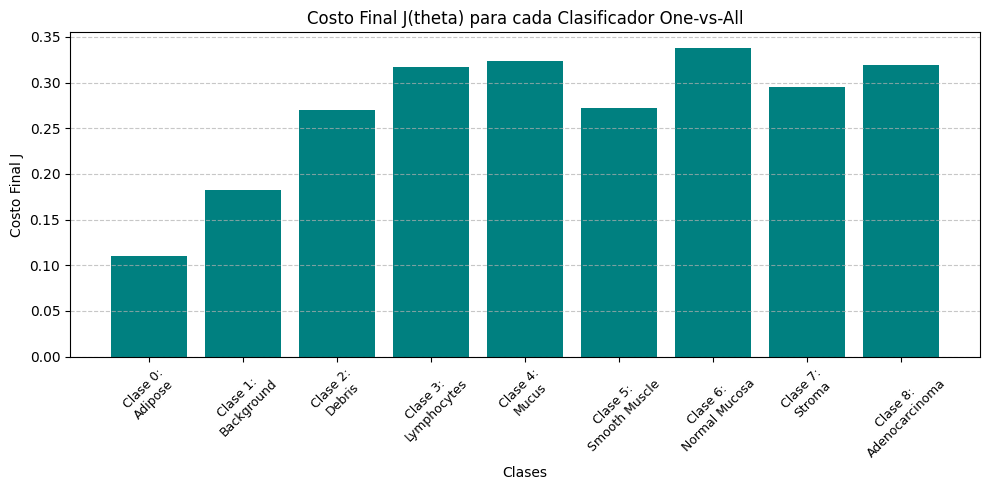

In [62]:
plt.figure(figsize=(10, 5))
plt.bar([f"Clase {i}:\n{class_names[i]}" for i in range(num_labels)], costos_finales, color='teal')
plt.title("Costo Final J(theta) para cada Clasificador One-vs-All")
plt.xlabel("Clases")
plt.ylabel("Costo Final J")
plt.xticks(rotation=45, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [63]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    X_ext = np.concatenate([np.ones((m, 1)), X], axis=1)
    probs = sigmoid(X_ext.dot(all_theta.T))
    return np.argmax(probs, axis=1)

pred_train = predictOneVsAll(all_theta, X_train)
acc_train = np.mean(pred_train == y_train) * 100

pred_test = predictOneVsAll(all_theta, X_test)
acc_test = np.mean(pred_test == y_test) * 100

print("=" * 55)
print(f"Precisión en Entrenamiento (Train 80%): {acc_train:.2f}%")
print(f"Precisión en Prueba (Test 20%):         {acc_test:.2f}%")
print("=" * 55)

Precisión en Entrenamiento (Train 80%): 47.64%
Precisión en Prueba (Test 20%):         42.09%


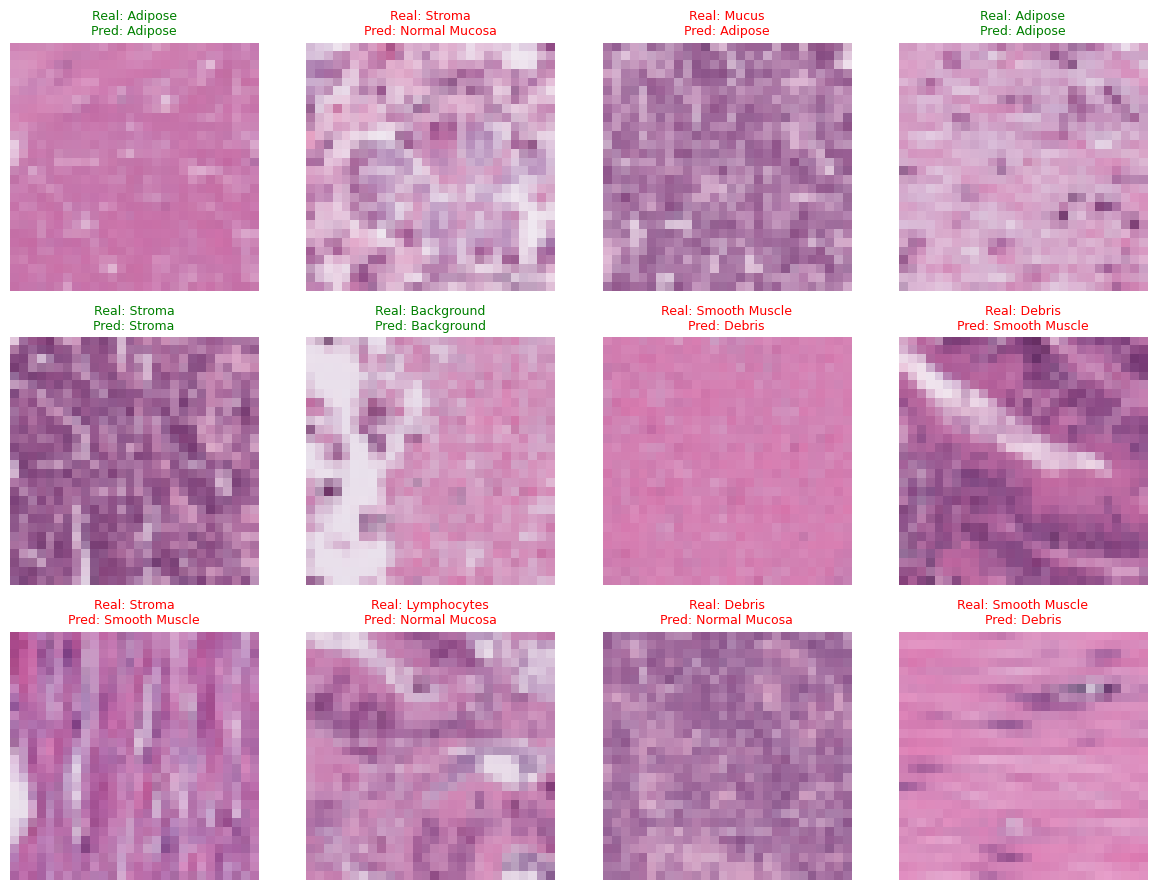

In [64]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
sample_indices = np.random.choice(len(X_test), 12, replace=False)

for i, idx in enumerate(sample_indices):
    ax = axes.flat[i]
    orig_idx = test_idx[idx]

    real_label = y_test[idx]
    pred_label = pred_test[idx]

    color = "green" if real_label == pred_label else "red"

    ax.imshow(X_raw[orig_idx])
    ax.set_title(f"Real: {class_names[real_label]}\nPred: {class_names[pred_label]}", color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()